Папка 'picture' уже существует

===== 1. Загрузка набора данных Ириса =====
Форма набора данных: (150, 7)

Первые 5 строк набора данных:
   Длина чашелистика (см)  Ширина чашелистика (см)  Длина лепестка (см)  \
0                     5.1                      3.5                  1.4   
1                     4.9                      3.0                  1.4   
2                     4.7                      3.2                  1.3   
3                     4.6                      3.1                  1.5   
4                     5.0                      3.6                  1.4   

   Ширина лепестка (см)          Вид  Код вида             Название вида  
0                   0.2  Iris-setosa         0  Ирис щетинистый (Setosa)  
1                   0.2  Iris-setosa         0  Ирис щетинистый (Setosa)  
2                   0.2  Iris-setosa         0  Ирис щетинистый (Setosa)  
3                   0.2  Iris-setosa         0  Ирис щетинистый (Setosa)  
4                   0.2  Iris-setosa 

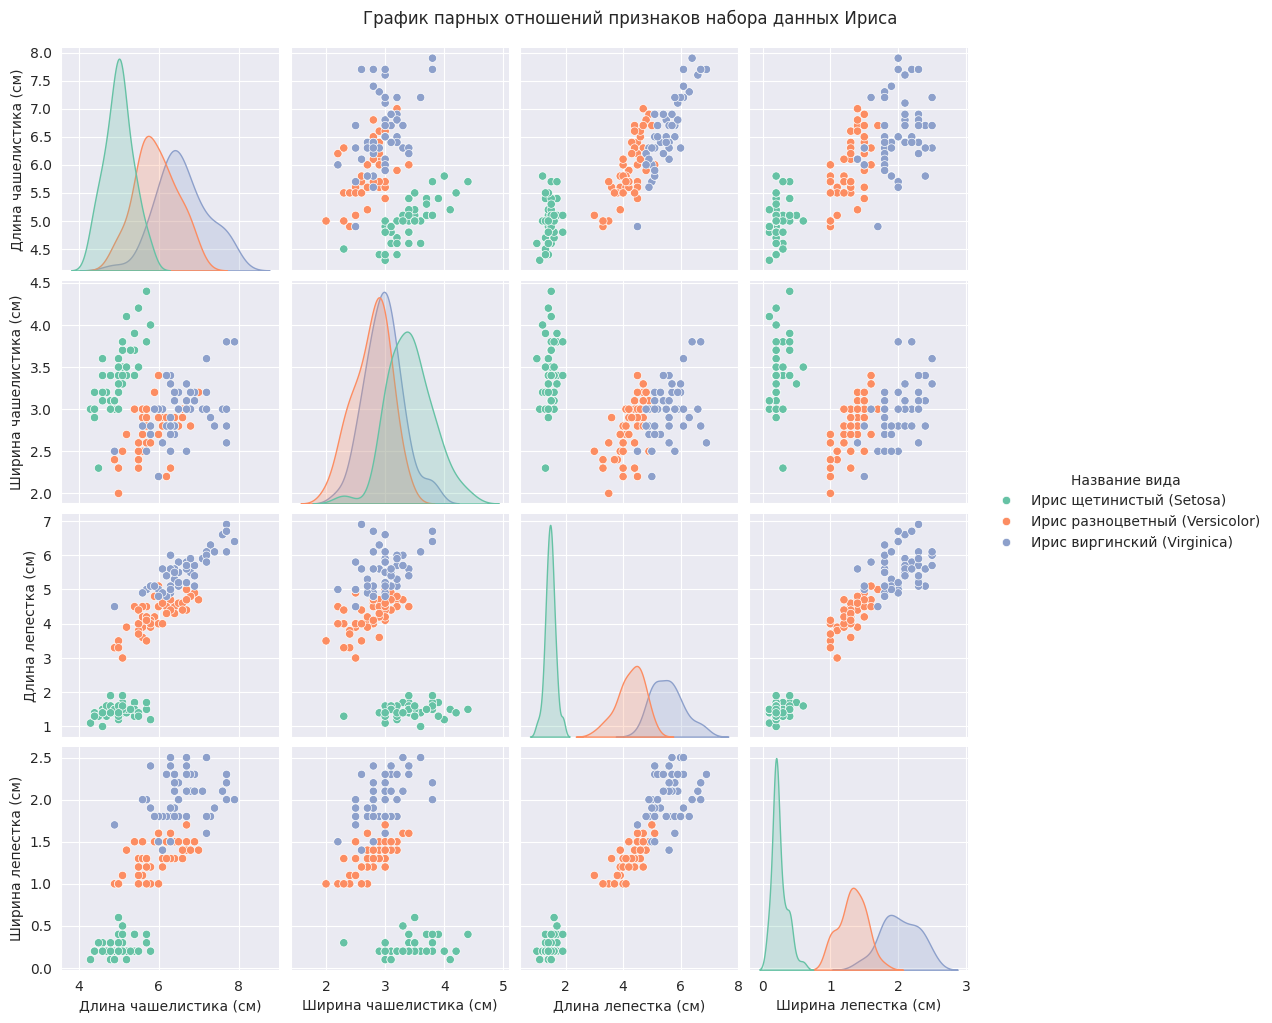


Выводы анализа Pairplot:
1. Ирис щетинистый (Setosa) имеет явное различие по длине/ширине лепестков с другими двумя видами, может быть линейно разделен;
2. Ирис разноцветный (Versicolor) и Ирис виргинский (Virginica) имеют перекрытие по некоторым признакам;
3. Признаки, связанные с лепестками (длина/ширина), вносят больший вклад в разделение видов, чем признаки чашелистика.


===== 3. Двухклассовая логистическая регрессия =====
Точность на обучающем наборе: 1.0000
Точность на тестовом наборе: 1.0000
Коэффициенты модели: [[ 0.52694542 -0.78063486  2.1168986   0.91030503]]
Перехват модели: [-6.93433052]


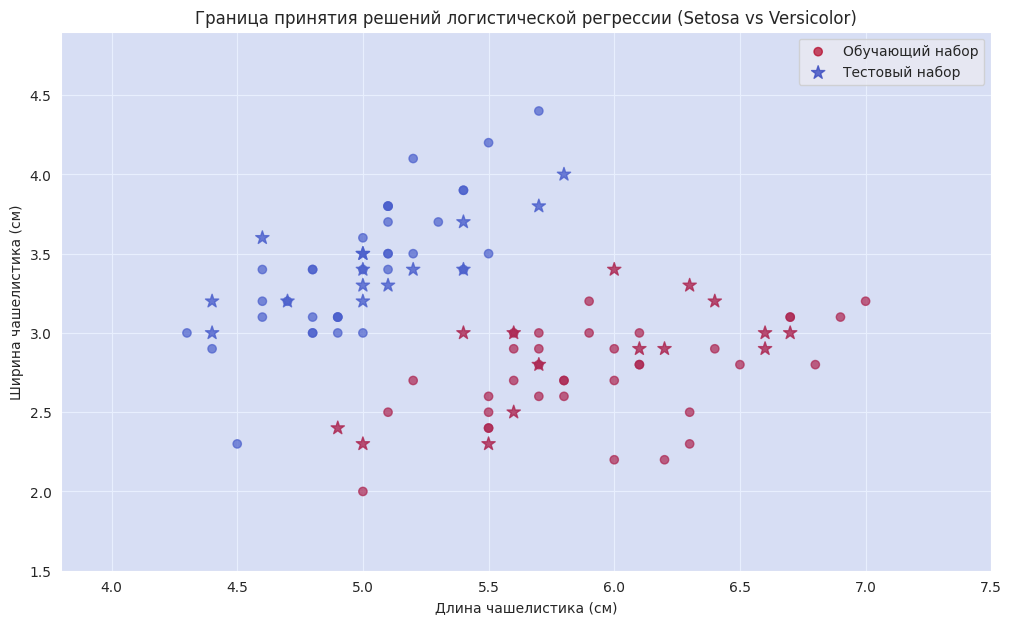


===== 4. Демонстрация переобучения линейной регрессии =====


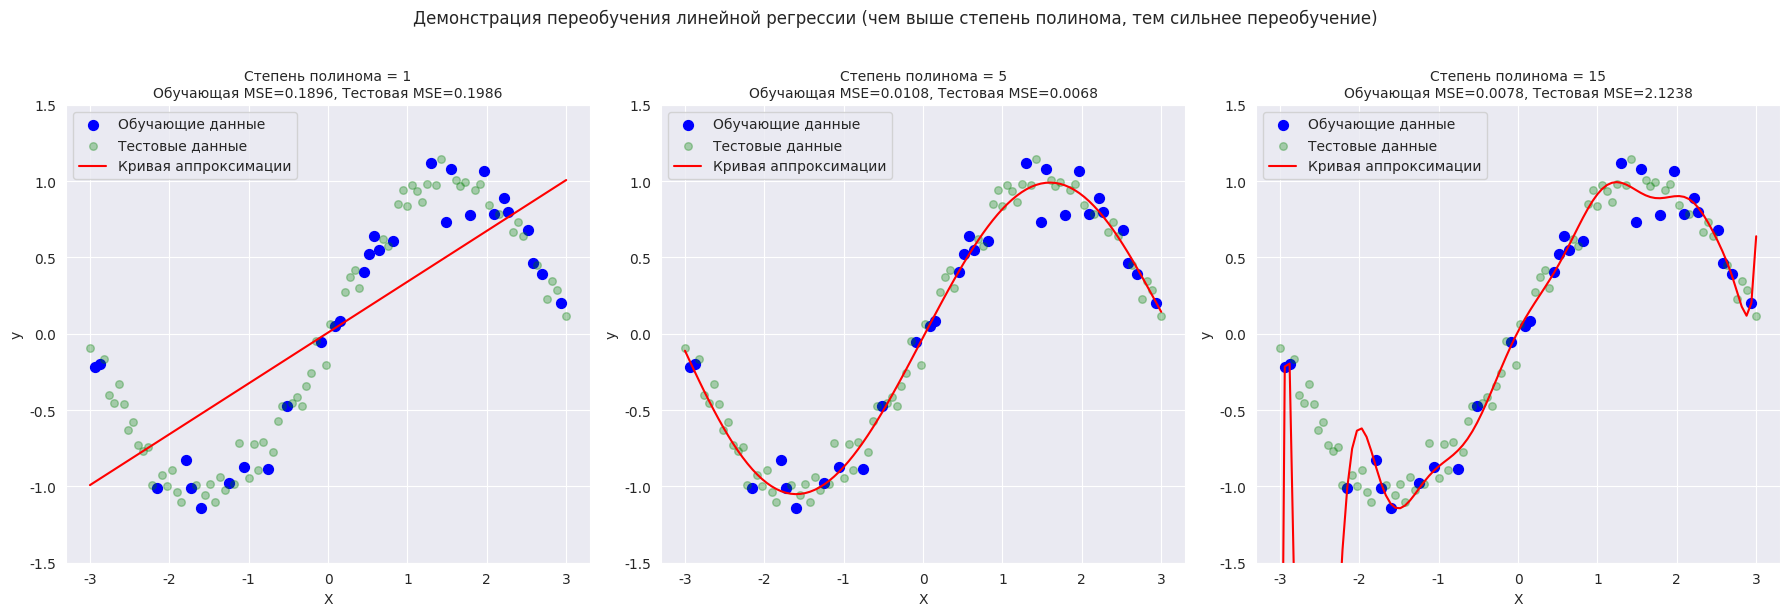


Анализ явления переобучения:
1. Степень полинома=1 (линейная): Недообучение, MSE на обучающем/тестовом наборах высокие, недостаточная сложность модели;
2. Степень полинома=5: Хорошая аппроксимация, MSE на обучающем/тестовом наборах низкие, умеренная сложность модели;
3. Степень полинома=15: Переобучение, MSE на обучающем наборе очень низкое, но MSE на тестовом наборе резко возрастает, модель чрезмерно учит шум обучающих данных.


===== Ответы на теоретические вопросы =====

1. Какова основная проблема переобучения?

        Основная проблема переобучения заключается в том, что модель чрезмерно адаптируется к обучающим данным, изучая не только реальные закономерности в данных, но и шум и случайные колебания обучающего набора.
        Проявление: модель показывает отличные результаты на обучающем наборе, но очень плохие на невиданном тестовом наборе, ее способность к обобщению крайне низка.
        Основная причина: сложность модели значительно выше сложности самих данных.
        

2. 

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
import warnings
import os  # Для работы с файловой системой
warnings.filterwarnings('ignore')

# ======================== Создание папки для изображений ========================
# Проверка существования папки 'picture', создание если не существует
if not os.path.exists('picture'):
    os.makedirs('picture')
    print("Папка 'picture' автоматически создана")
else:
    print("Папка 'picture' уже существует")

# Настройка шрифтов для корректного отображения русского языка
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# ======================== 1. Загрузка набора данных Ириса (из UCI) ========================
print("\n===== 1. Загрузка набора данных Ириса =====")
# Прямая загрузка исходного набора данных Ириса из UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
# Определение названий столбцов (на русском)
column_names = [
    'Длина чашелистика (см)',
    'Ширина чашелистика (см)',
    'Длина лепестка (см)',
    'Ширина лепестка (см)',
    'Вид'
]
# Чтение набора данных
iris_df = pd.read_csv(url, header=None, names=column_names)

# Обработка названий видов (маппинг на русские наименования)
species_mapping_ru = {
    'Iris-setosa': 'Ирис щетинистый (Setosa)',
    'Iris-versicolor': 'Ирис разноцветный (Versicolor)',
    'Iris-virginica': 'Ирис виргинский (Virginica)'
}
species_mapping_num = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
iris_df['Код вида'] = iris_df['Вид'].map(species_mapping_num)
iris_df['Название вида'] = iris_df['Вид'].map(species_mapping_ru)

# Просмотр основной информации о наборе данных
print("Форма набора данных:", iris_df.shape)
print("\nПервые 5 строк набора данных:")
print(iris_df.head())
print("\nОписательная статистика набора данных:")
print(iris_df.describe())
print("\nРаспределение видов:")
print(iris_df['Название вида'].value_counts())

# ======================== 2. Визуализация данных (pairplot) ========================
print("\n===== 2. Визуализация данных (pairplot) =====")
# Выбор столбцов с признаками для pairplot
feature_cols = [
    'Длина чашелистика (см)',
    'Ширина чашелистика (см)',
    'Длина лепестка (см)',
    'Ширина лепестка (см)'
]
# Построение pairplot с раскраской по видам
sns.pairplot(iris_df, hue='Название вида', vars=feature_cols, palette='Set2')
plt.suptitle('График парных отношений признаков набора данных Ириса', y=1.02)
plt.savefig('picture/pairplot_iris.png', dpi=300, bbox_inches='tight')
plt.show()

# Анализ результатов визуализации
print("""
Выводы анализа Pairplot:
1. Ирис щетинистый (Setosa) имеет явное различие по длине/ширине лепестков с другими двумя видами, может быть линейно разделен;
2. Ирис разноцветный (Versicolor) и Ирис виргинский (Virginica) имеют перекрытие по некоторым признакам;
3. Признаки, связанные с лепестками (длина/ширина), вносят больший вклад в разделение видов, чем признаки чашелистика.
""")

# ======================== 3. Двухклассовая логистическая регрессия ========================
print("\n===== 3. Двухклассовая логистическая регрессия =====")
# Создание набора данных для двухклассовой классификации (Setosa vs Versicolor)
binary_iris = iris_df[iris_df['Код вида'].isin([0, 1])].copy()
X_binary = binary_iris[feature_cols]  # Признаки
y_binary = binary_iris['Код вида']    # Метки

# Разделение на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# Обучение модели логистической регрессии
lr_model = LogisticRegression(random_state=42, max_iter=200)
lr_model.fit(X_train, y_train)

# Предсказание и оценка модели
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Точность на обучающем наборе: {train_acc:.4f}")
print(f"Точность на тестовом наборе: {test_acc:.4f}")
print(f"Коэффициенты модели: {lr_model.coef_}")
print(f"Перехват модели: {lr_model.intercept_}")

# Визуализация границы принятия решений (выбор первых двух признаков)
plt.figure(figsize=(12, 7))
# Отображение обучающих данных
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, cmap='coolwarm', label='Обучающий набор', alpha=0.7)
# Отображение тестовых данных
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, cmap='coolwarm', label='Тестовый набор', marker='*', s=100, alpha=0.8)

# Построение границы принятия решений
x1_min, x1_max = X_binary.iloc[:, 0].min() - 0.5, X_binary.iloc[:, 0].max() + 0.5
x2_min, x2_max = X_binary.iloc[:, 1].min() - 0.5, X_binary.iloc[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))
# Формирование матрицы признаков (для 4 признаков, последние два заполнены нулями)
X_grid = np.c_[xx1.ravel(), xx2.ravel(), np.zeros_like(xx1.ravel()), np.zeros_like(xx1.ravel())]
Z = lr_model.predict(X_grid)
Z = Z.reshape(xx1.shape)
plt.contourf(xx1, xx2, Z, alpha=0.2, cmap='coolwarm')

plt.xlabel(feature_cols[0])
plt.ylabel(feature_cols[1])
plt.title('Граница принятия решений логистической регрессии (Setosa vs Versicolor)', fontsize=12)
plt.legend()
plt.savefig('picture/logistic_regression_binary.png', dpi=300, bbox_inches='tight')
plt.show()

# ======================== 4. Демонстрация переобучения линейной регрессии ========================
print("\n===== 4. Демонстрация переобучения линейной регрессии =====")
# Генерация симулированных данных (нелинейная зависимость)
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)  # Независимая переменная
y = np.sin(X).ravel() + np.random.normal(0, 0.1, size=X.shape[0])  # Зависимая переменная (с шумом)

# Разделение на обучающий (малое количество образцов) и тестовый наборы
X_train_small, X_test, y_train_small, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42
)

# Определение полиномиальных признаков разной сложности
degrees = [1, 5, 15]  # Низкая, средняя, высокая сложность
plt.figure(figsize=(18, 6))

for i, degree in enumerate(degrees):
    # Генерация полиномиальных признаков
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_small)
    X_test_poly = poly.transform(X_test)
    X_full_poly = poly.transform(X)  # Для построения кривой аппроксимации

    # Обучение модели линейной регрессии
    lr = LinearRegression()
    lr.fit(X_train_poly, y_train_small)

    # Предсказание и расчет MSE
    y_train_pred = lr.predict(X_train_poly)
    y_test_pred = lr.predict(X_test_poly)
    train_mse = mean_squared_error(y_train_small, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Отображение результатов
    plt.subplot(1, 3, i+1)
    plt.scatter(X_train_small, y_train_small, label='Обучающие данные', color='blue', s=50)
    plt.scatter(X_test, y_test, label='Тестовые данные', color='green', alpha=0.3, s=30)
    plt.plot(X, lr.predict(X_full_poly), color='red', label='Кривая аппроксимации')
    plt.title(f'Степень полинома = {degree}\nОбучающая MSE={train_mse:.4f}, Тестовая MSE={test_mse:.4f}', fontsize=10)
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.ylim(-1.5, 1.5)

plt.suptitle('Демонстрация переобучения линейной регрессии (чем выше степень полинома, тем сильнее переобучение)', y=1.02)
plt.tight_layout()
plt.savefig('picture/overfitting_demo.png', dpi=300, bbox_inches='tight')
plt.show()

# Анализ явления переобучения
print("""
Анализ явления переобучения:
1. Степень полинома=1 (линейная): Недообучение, MSE на обучающем/тестовом наборах высокие, недостаточная сложность модели;
2. Степень полинома=5: Хорошая аппроксимация, MSE на обучающем/тестовом наборах низкие, умеренная сложность модели;
3. Степень полинома=15: Переобучение, MSE на обучающем наборе очень низкое, но MSE на тестовом наборе резко возрастает, модель чрезмерно учит шум обучающих данных.
""")

# ======================== Ответы на теоретические вопросы ========================
print("\n===== Ответы на теоретические вопросы =====")
theory_answers = {
    "1. Какова основная проблема переобучения?":
        """
        Основная проблема переобучения заключается в том, что модель чрезмерно адаптируется к обучающим данным, изучая не только реальные закономерности в данных, но и шум и случайные колебания обучающего набора.
        Проявление: модель показывает отличные результаты на обучающем наборе, но очень плохие на невиданном тестовом наборе, ее способность к обобщению крайне низка.
        Основная причина: сложность модели значительно выше сложности самих данных.
        """,
    "2. Почему мы не можем оценить качество модели на данных, использованных для ее обучения?":
        """
        Потому что обучающие данные являются "материалом" для обучения модели, и модель старается максимально адаптироваться к этим данным (особенно сложные модели).
        Оценка только по обучающим данным переоценивает производительность модели и не отражает ее способность к обобщению на новые данные.
        Правильный подход: разделить данные на обучающий и тестовый наборы, обучить модель на обучающем наборе и оценить ее реальную производительность на тестовом наборе.
        """,
    "3. Что такое регуляризация и как она помогает бороться с сложностью модели?":
        """
        Регуляризация — это техника, которая ограничивает размер параметров модели путем добавления штрафного члена в функцию потерь, целью является снижение сложности модели и предотвращение переобучения.
        Распространенные виды регуляризации: L1 (Lasso) и L2 (Ridge):
        - L1-регуляризация: штрафует сумму абсолютных значений параметров, может привести к тому, что некоторые параметры станут равными 0, реализуя выбор признаков;
        - L2-регуляризация: штрафует сумму квадратов параметров, заставляя все параметры приближаться к 0, но не становясь им, предотвращая чрезмерно большие значения параметров.
        Регуляризация ограничивает пространство параметров, делая модель "простее", тем самым снижая зависимость от шума обучающих данных и повышая способность к обобщению.
        """
}

for question, answer in theory_answers.items():
    print(f"\n{question}")
    print(answer)

# ======================== Основное содержание отчета по эксперименту ========================
print("\n===== Основное содержание отчета по эксперименту =====")
report = f"""
# Отчет по эксперименту по основам машинного обучения
## Цель эксперимента
1. Освоить методы загрузки, предварительной обработки и визуализации набора данных Ириса;
2. Реализовать построение модели логистической регрессии и задачу двухклассовой классификации;
3. Понять и продемонстрировать явление переобучения модели линейной регрессии;
4. Освоить базовый процесс контроля версий Git.

## Ссылка на репозиторий Git
(Пожалуйста, замените на адрес вашего удаленного репозитория, например: https://github.com/your-username/your-repo)

## Итог результатов эксперимента
1. Визуализация данных: признаки лепестков набора данных Ириса более эффективны для разделения видов, ирис щетинистый может быть линейно разделен от двух других видов;
2. Двухклассовая логистическая регрессия: в задаче Setosa vs Versicolor точность модели на обучающем наборе {train_acc:.4f}, на тестовом наборе {test_acc:.4f}, хорошая способность к обобщению;
3. Демонстрация переобучения: чем выше степень полинома, тем лучше модель адаптируется к обучающим данным, но тем больше ошибка предсказания на тестовых данных, что отражает основные черты переобучения.

## Выводы
1. Визуализация данных является важным средством для понимания распределения данных и корреляции признаков;
2. Логистическая регрессия — это простая и эффективная модель для двухклассовой классификации, подходящая для линейно разделимых данных;
3. Сложность модели должна соответствовать сложности данных, чрезмерно высокая сложность приводит к переобучению;
4. Методы регуляризации, увеличения данных, ранней остановки и др. могут эффективно смягчить проблему переобучения.
"""

print(report)